# 과제

이효석의 '벽공무한'과 강경애의 '인간문제'를 형태소 분석하고 명사표지 중 NNP, NNG (일반명사, 고유명사) 그리고 동사(VV)와 형용사(VA)의 차이를 matplolib으로 그래프를 그려라.

In [ ]:
from kiwipiepy import Kiwi

kiwi = Kiwi()

text = "차례나 성묘 대신 조부모, 부모, 아이가 함께 떠나는 ‘다세대 가족여행’이 새로운 명절 트렌드로 자리 잡고 있다."
result = kiwi.tokenize(text)

for token in result:
    print(token.form, token.tag, sep = '_', end = ' ')

차례_NNG 나_JC 성묘_NNG 대신_NNG 조부모_NNG ,_SP 부모_NNG ,_SP 아이_NNG 가_JKS 함께_MAG 떠나_VV 는_ETM ‘_SSO 다세대_NNG 가족_NNG 여행_NNG ’_SSC 이_JKS 새롭_VA-I 은_ETM 명절_NNG 트렌드_NNG 로_JKB 자리_NNG 잡_VV-R 고_EC 있_VX 다_EF ._SF 

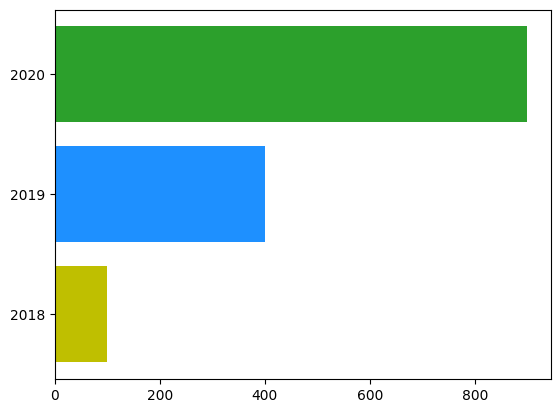

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

y = np.arange(3)
years = ['2018', '2019', '2020']
values = [100, 400, 900]
colors = ['y', 'dodgerblue', 'C2']

plt.barh(y, values, color=colors)
plt.yticks(y, years)

plt.show()

## 과제 1번. 형태소 분석

In [1]:
pip install kiwipiepy matplotlib

In [2]:
# 필요한 라이브러리 임포트
import matplotlib.pyplot as plt
from kiwipiepy import Kiwi
from collections import Counter
import numpy as np
from google.colab import files

In [3]:
# 파일 업로드
uploaded = files.upload()

# 업로드된 파일 이름을 변수에 저장
file_human_problem = '강경애-인간문제-동아일보.txt'
file_infinity = '이효석-벽공무한.txt'

print(f"\n'{file_human_problem}'와 '{file_infinity}' 파일 업로드 성공")

Saving 강경애-인간문제-동아일보.txt to 강경애-인간문제-동아일보.txt
Saving 이효석-벽공무한.txt to 이효석-벽공무한.txt

'강경애-인간문제-동아일보.txt'와 '이효석-벽공무한.txt' 파일 업로드 성공


In [4]:
def analyze_pos(filepath):
    # 형태소를 분석하고 지정된 품사(NNG, NNP, VV, VA)의 빈도를 계산
    kiwi = Kiwi()
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            text = f.read()
    except FileNotFoundError:
        print(f"오류: '{filepath}' 파일을 찾을 수 없습니다.")
        return None

    result = kiwi.tokenize(text)

    # 분석 결과에서 품사(POS) 태그만 추출
    pos_tags = [token.tag for token in result]

    # 일반 명사, 고유 명사, 동사, 형용사
    target_tags = ['NNG', 'NNP', 'VV', 'VA']
    filtered_tags = [tag for tag in pos_tags if tag in target_tags]

    # Counter를 사용해 필터링된 품사들의 빈도를 계산
    counts = Counter(filtered_tags)

    return counts

In [5]:
# 각 소설 파일에 대해 형태소 분석을 수행
counts_human_problem = analyze_pos(file_human_problem)
counts_infinity = analyze_pos(file_infinity)

if counts_human_problem and counts_infinity:
    tags = ['NNG', 'NNP', 'VV', 'VA']
    labels = ['NNG', 'NNP', 'VV', 'VA']

    # 각 소설의 품사별 빈도수를 리스트로
    values_human_problem = [counts_human_problem[tag] for tag in tags]
    values_infinity = [counts_infinity[tag] for tag in tags]

    print("Data analysis and graph preparation complete.")
    print("\n강경애 - 인간문제:", dict(zip(labels, values_human_problem)))
    print("이효석 - 벽공무한:", dict(zip(labels, values_infinity)))

Data analysis and graph preparation complete.

강경애 - 인간문제: {'NNG': 19056, 'NNP': 3125, 'VV': 13931, 'VA': 1600}
이효석 - 벽공무한: {'NNG': 27037, 'NNP': 2494, 'VV': 11564, 'VA': 2753}


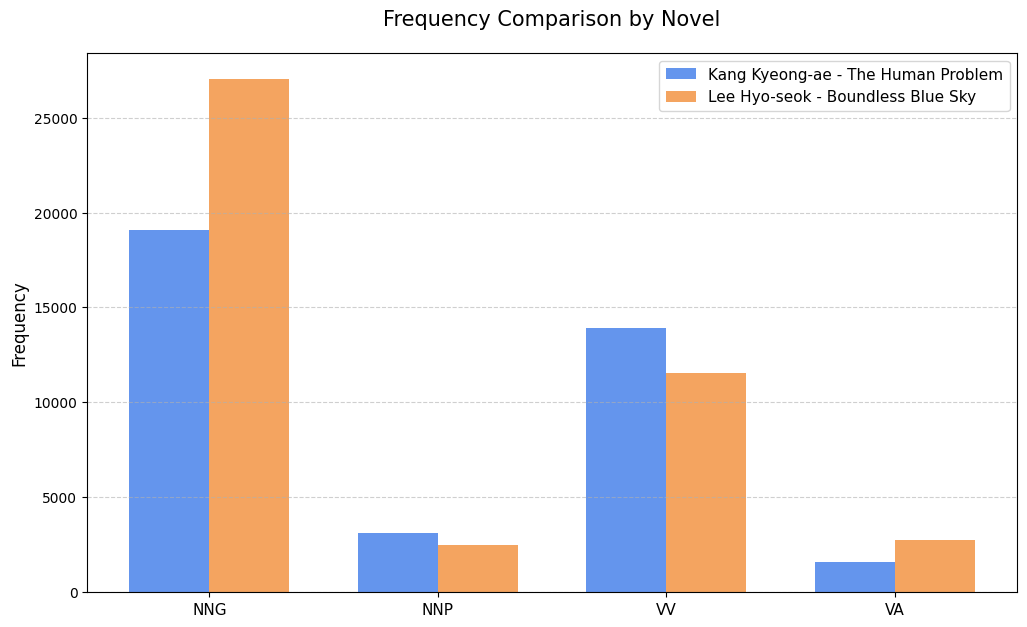

In [6]:
# 그래프 크기 설정
plt.figure(figsize=(12, 7))

# 막대그래프를 그리기 위한 x축 위치와 막대 폭 설정
x = np.arange(len(labels))
width = 0.35

# 막대그래프 생성
# 한글 폰트가 깨져서 영어로 라벨 작성함
plt.bar(x - width/2, values_human_problem, width, label='Kang Kyeong-ae - The Human Problem', color='cornflowerblue')
plt.bar(x + width/2, values_infinity, width, label='Lee Hyo-seok - Boundless Blue Sky', color='sandybrown')

# 축 레이블 및 제목, 범례 설정
plt.ylabel('Frequency', fontsize=12)
plt.title('Frequency Comparison by Novel', fontsize=15, pad=20)
plt.xticks(x, labels, fontsize=11)
plt.legend(fontsize=11)

# 그래프 상단에 그리드 추가
plt.grid(True, axis='y', linestyle='--', alpha=0.6)

# 그래프 출력
plt.show()